# Social Determinants of Health — Advanced Visualizations
**Keystone Project | Module 3 — Week 4: Polished Visuals + Visual Integrity**

This notebook transforms exploratory charts from Week 2 into polished,
ethical, intentional visualizations that communicate a clear story.

---

## Part 1: Ethics Reflection

Before creating any visuals, I examined the dataset through an ethics lens:

**Potential biases and limitations:**
- County-level data averages conditions across entire counties — hiding disparities within them
- Racial poverty breakdowns are missing for small rural counties, which may understate disparities
- Distance to healthcare is median miles — not whether someone has a car, insurance, or time off
- The vulnerability score weights all 5 factors equally — some may matter more in reality

**How I addressed this:**
- Added disclaimers in chart notes where limitations apply
- Used neutral titles that describe data, not conclusions
- Avoided language implying causation when only correlation is shown
- Included data source citation on every chart

## Part 2: Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from numpy.polynomial.polynomial import polyfit

plt.rcParams.update({
    'figure.figsize':    (11, 5),
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.size':         11,
    'axes.titlesize':    13,
    'axes.titleweight':  'bold',
    'axes.titlepad':     14,
    'axes.labelsize':    11,
    'xtick.labelsize':   10,
    'ytick.labelsize':   10,
})

SOURCE_TEXT   = 'Data source: AHRQ Community Level Health Dataset, 2023 (county level)'
region_colors = {'South': '#E84B4B', 'West': '#EF9F27', 'Midwest': '#4878CF', 'Northeast': '#3B6D11'}

df = pd.read_csv('data/sdoh_county_2023.csv', dtype={'county_fips': str})
df = df.dropna(subset=['poverty_pct', 'uninsured_pct', 'broadband_pct'])

print(f"Loaded: {df.shape[0]:,} counties")


Loaded: 3,143 counties


## Chart 1: Four Hardship Indicators by Region

**Question:** How do poverty, uninsured rate, unemployment, and lack of broadband
compare across Census regions?

**Why grouped bar:** Lets the reader compare individual indicators side by side
without implying they add up to a single total.

**Design choices:** Same blue color family in four shades — same category, no
implied ranking between indicators. Sorted by overall burden (South highest).
Y-axis at zero. Source cited.

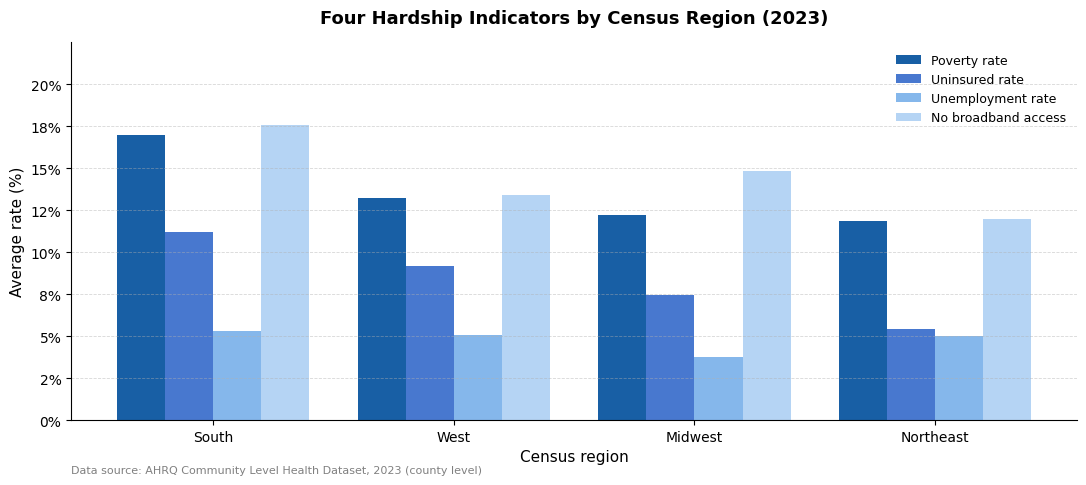

In [2]:
# Group and sort regions by total hardship burden
region_data = df.groupby('region').agg(
    Poverty      = ('poverty_pct',    'mean'),
    Uninsured    = ('uninsured_pct',  'mean'),
    Unemployment = ('unemployment_pct','mean'),
    No_Broadband = ('broadband_pct',  lambda x: 100 - x.mean())
).round(2)
region_data = region_data.reindex(region_data.sum(axis=1).sort_values(ascending=False).index)

x      = np.arange(len(region_data))
width  = 0.2
colors = ['#185FA5', '#4878CF', '#85B7EB', '#B5D4F4']
labels = ['Poverty rate', 'Uninsured rate', 'Unemployment rate', 'No broadband access']

fig, ax = plt.subplots()
for i, (col, color, label) in enumerate(zip(region_data.columns, colors, labels)):
    ax.bar(x + i * width, region_data[col], width, color=color, label=label, edgecolor='none')

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(region_data.index)
ax.set_ylim(0, region_data.values.max() * 1.28)
ax.set_title('Four Hardship Indicators by Census Region (2023)')
ax.set_xlabel('Census region')
ax.set_ylabel('Average rate (%)')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax.legend(fontsize=9, frameon=False, loc='upper right')
ax.grid(axis='y', linestyle='--', linewidth=0.6, alpha=0.5)
ax.text(0, -0.14, SOURCE_TEXT, transform=ax.transAxes, fontsize=8, color='gray')
plt.tight_layout()
plt.show()


## Chart 2: Poverty vs. Uninsured Rate

**Question:** Is there a relationship between poverty and lack of insurance?

**Why scatter:** Shows the relationship between two numeric variables across 3,000+ counties.

**Design choices:** Small semi-transparent points avoid overplotting. Trend line
in dark gray — neutral. Correlation stated explicitly so readers don't have to infer it.

**Accuracy note:** Correlation does not imply causation.

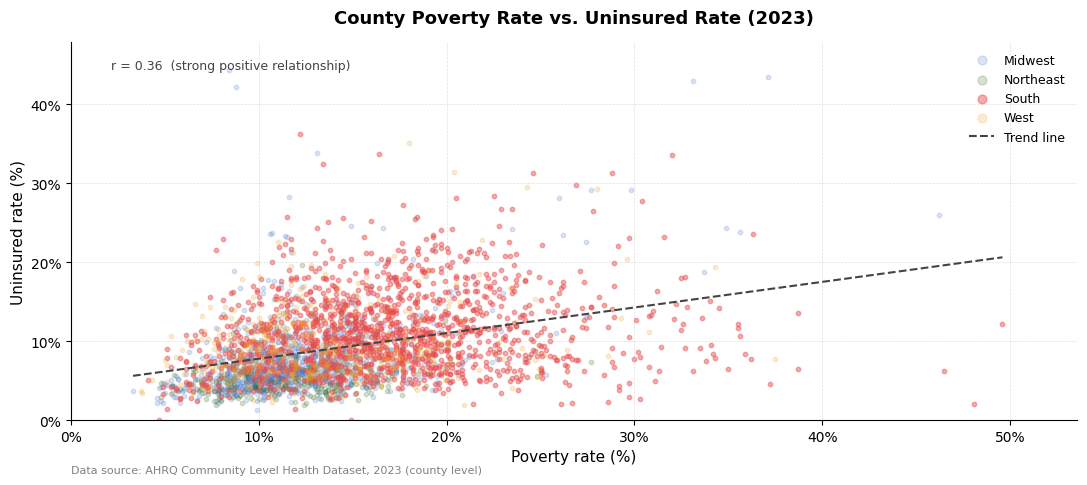

In [3]:
clean = df[['poverty_pct', 'uninsured_pct']].dropna()
b, m  = polyfit(clean['poverty_pct'], clean['uninsured_pct'], 1)
x_line = np.linspace(clean['poverty_pct'].min(), clean['poverty_pct'].max(), 100)
corr  = clean.corr().iloc[0, 1]

fig, ax = plt.subplots()
for region, grp in df.groupby('region'):
    alpha = 0.45 if region == 'South' else 0.2
    ax.scatter(grp['poverty_pct'], grp['uninsured_pct'],
               color=region_colors[region], s=10, alpha=alpha, label=region)

ax.plot(x_line, b + m * x_line, color='#444441', linewidth=1.5, linestyle='--', label='Trend line')
ax.annotate(f'r = {corr:.2f}  (strong positive relationship)',
            xy=(0.04, 0.93), xycoords='axes fraction', fontsize=9, color='#444441')

ax.set_title('County Poverty Rate vs. Uninsured Rate (2023)')
ax.set_xlabel('Poverty rate (%)')
ax.set_ylabel('Uninsured rate (%)')
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax.set_xlim(0, df['poverty_pct'].max() * 1.08)
ax.set_ylim(0, df['uninsured_pct'].max() * 1.08)
ax.legend(fontsize=9, frameon=False, markerscale=2)
ax.grid(linestyle='--', linewidth=0.5, alpha=0.4)
ax.text(0, -0.14, SOURCE_TEXT, transform=ax.transAxes, fontsize=8, color='gray')
plt.tight_layout()
plt.show()


## Chart 3: Racial Poverty Gap by Region

**Question:** How large is the gap between Black, Hispanic, and White poverty rates?

**Why horizontal grouped bar:** Easy to compare three groups across four regions.

**Design choices:** Three distinct accessible colors. Reference line at national
average gives readers a baseline. Sorted by Black poverty rate (highest burden first).

**Accuracy note:** These rates represent average poverty rate *for people of that race*
within each county — not the overall share of the population in poverty.

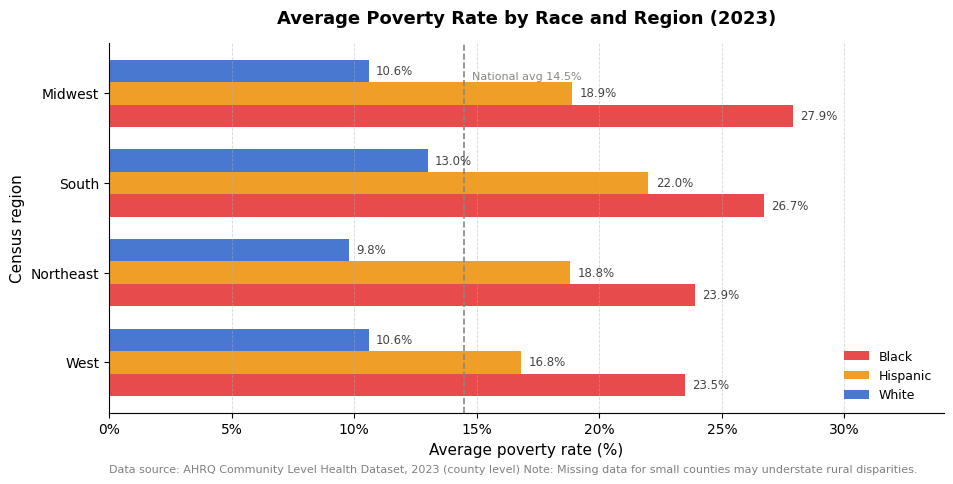

In [4]:
racial = df.groupby('region').agg(
    Black    = ('poverty_pct_black',    'mean'),
    Hispanic = ('poverty_pct_hispanic', 'mean'),
    White    = ('poverty_pct_white',    'mean'),
).round(1).sort_values('Black', ascending=True)

y      = np.arange(len(racial))
height = 0.25
colors3 = ['#E84B4B', '#EF9F27', '#4878CF']
groups  = ['Black', 'Hispanic', 'White']

fig, ax = plt.subplots(figsize=(10, 5))
for i, (grp, color) in enumerate(zip(groups, colors3)):
    bars = ax.barh(y + i * height, racial[grp], height, color=color, label=grp, edgecolor='none')
    for bar in bars:
        w = bar.get_width()
        ax.text(w + 0.3, bar.get_y() + bar.get_height() / 2,
                f'{w:.1f}%', va='center', fontsize=8.5, color='#444441')

national_avg = df['poverty_pct'].mean()
ax.axvline(national_avg, color='#888780', linewidth=1.2, linestyle='--')
ax.text(national_avg + 0.3, len(racial) * 0.75 + 0.4,
        f'National avg {national_avg:.1f}%', fontsize=8, color='#888780')

ax.set_yticks(y + height)
ax.set_yticklabels(racial.index)
ax.set_xlim(0, racial.values.max() * 1.22)
ax.set_title('Average Poverty Rate by Race and Region (2023)')
ax.set_xlabel('Average poverty rate (%)')
ax.set_ylabel('Census region')
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax.legend(fontsize=9, frameon=False, loc='lower right')
ax.grid(axis='x', linestyle='--', linewidth=0.6, alpha=0.5)
ax.text(0, -0.16, SOURCE_TEXT + ' Note: Missing data for small counties may understate rural disparities.',
        transform=ax.transAxes, fontsize=8, color='gray')
plt.tight_layout()
plt.show()


## Chart 4: Broadband Access vs. Poverty

**Question:** Do poorer counties have less broadband — and what does that mean for telehealth?

**Why scatter:** Shows whether two variables move together across all counties.

**Design choices:** Both axes start at zero. Trend line clearly labeled.
Annotation explains the telehealth implication directly rather than leaving readers to infer it.

**Accuracy note:** Correlation only — broadband gaps have many causes beyond poverty alone.

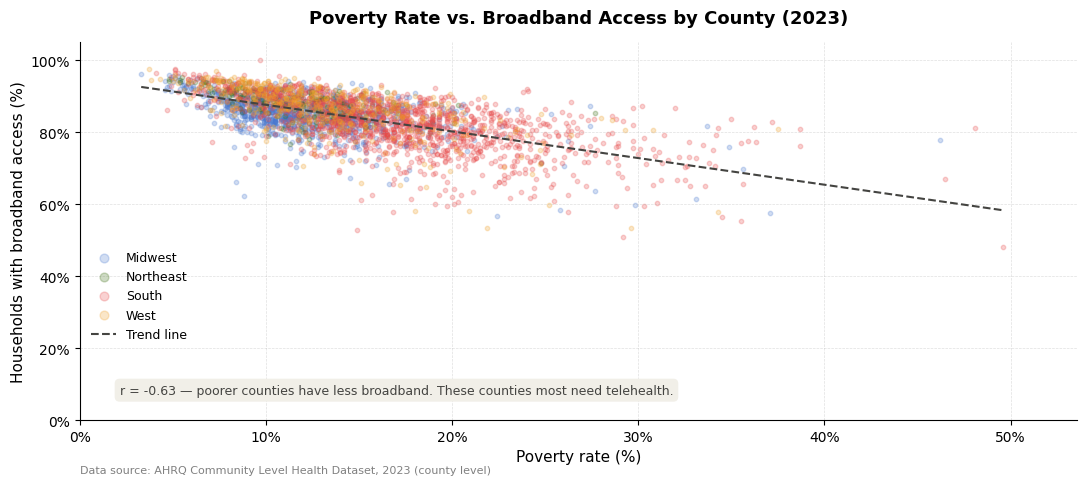

In [5]:
clean2 = df[['poverty_pct', 'broadband_pct']].dropna()
b2, m2 = polyfit(clean2['poverty_pct'], clean2['broadband_pct'], 1)
x2     = np.linspace(clean2['poverty_pct'].min(), clean2['poverty_pct'].max(), 100)
corr2  = clean2.corr().iloc[0, 1]

fig, ax = plt.subplots()
for region, grp in df.groupby('region'):
    ax.scatter(grp['poverty_pct'], grp['broadband_pct'],
               color=region_colors[region], s=10, alpha=0.25, label=region)

ax.plot(x2, b2 + m2 * x2, color='#444441', linewidth=1.5, linestyle='--', label='Trend line')
ax.annotate(
    f'r = {corr2:.2f} — poorer counties have less broadband. These counties most need telehealth.',
    xy=(0.04, 0.07), xycoords='axes fraction', fontsize=9, color='#444441',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='#F1EFE8', edgecolor='none'))

ax.set_xlim(0, df['poverty_pct'].max() * 1.08)
ax.set_ylim(0, 105)
ax.set_title('Poverty Rate vs. Broadband Access by County (2023)')
ax.set_xlabel('Poverty rate (%)')
ax.set_ylabel('Households with broadband access (%)')
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax.legend(fontsize=9, frameon=False, markerscale=2, loc='lower left', bbox_to_anchor=(0.0, 0.18))
ax.grid(linestyle='--', linewidth=0.5, alpha=0.4)
ax.text(0, -0.14, SOURCE_TEXT, transform=ax.transAxes, fontsize=8, color='gray')
plt.tight_layout()
plt.show()


## Chart 5: Vulnerability Score Distribution

**Question:** How are U.S. counties distributed across vulnerability levels?

**Why histogram:** Shows the full distribution — averages hide that most counties
cluster at moderate vulnerability while a significant tail suffers extreme hardship.

**Design choices:** Three shades of blue — darker = higher vulnerability. No alarming red.
Percentile lines give context. Color zones labeled with county counts.

**Accuracy note:** Vulnerability score is a simple equal-weight average of 5 indicators —
a summary tool, not a definitive ranking.

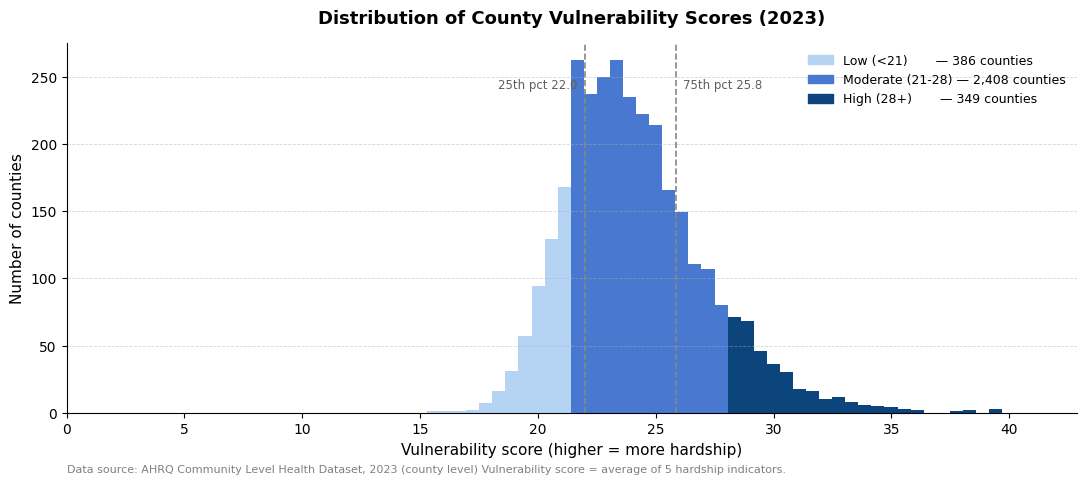

Low vulnerability  (<21):  386 counties
Moderate  (21-28):         2,408 counties
High vulnerability (28+):  349 counties


In [6]:
scores = df['vulnerability_score'].dropna()
bins   = np.linspace(scores.min(), scores.max(), 45)

fig, ax = plt.subplots()
n, edges, patches = ax.hist(scores, bins=bins, edgecolor='none')

for patch, left_edge in zip(patches, bins[:-1]):
    if left_edge < 21:    patch.set_facecolor('#B5D4F4')
    elif left_edge < 28:  patch.set_facecolor('#4878CF')
    else:                 patch.set_facecolor('#0C447C')

p25, p75 = scores.quantile(0.25), scores.quantile(0.75)
ax.axvline(p25, color='#888780', linewidth=1.2, linestyle='--')
ax.axvline(p75, color='#888780', linewidth=1.2, linestyle='--')
ax.text(p25 - 0.3, n.max() * 0.92, '25th pct ' + f'{p25:.1f}', ha='right', fontsize=8.5, color='#5F5E5A')
ax.text(p75 + 0.3, n.max() * 0.92, '75th pct ' + f'{p75:.1f}', ha='left', fontsize=8.5, color='#5F5E5A')

legend_patches = [
    mpatches.Patch(color='#B5D4F4', label=f'Low (<21)       — {(scores < 21).sum():,} counties'),
    mpatches.Patch(color='#4878CF', label=f'Moderate (21-28) — {((scores>=21)&(scores<28)).sum():,} counties'),
    mpatches.Patch(color='#0C447C', label=f'High (28+)       — {(scores >= 28).sum():,} counties'),
]
ax.legend(handles=legend_patches, fontsize=9, frameon=False, loc='upper right')

ax.set_title('Distribution of County Vulnerability Scores (2023)')
ax.set_xlabel('Vulnerability score (higher = more hardship)')
ax.set_ylabel('Number of counties')
ax.set_xlim(0, scores.max() * 1.08)
ax.grid(axis='y', linestyle='--', linewidth=0.6, alpha=0.5)
ax.text(0, -0.16, SOURCE_TEXT + ' Vulnerability score = average of 5 hardship indicators.',
        transform=ax.transAxes, fontsize=8, color='gray')
plt.tight_layout()
plt.show()

print(f"Low vulnerability  (<21):  {(scores < 21).sum():,} counties")
print(f"Moderate  (21-28):         {((scores>=21)&(scores<28)).sum():,} counties")
print(f"High vulnerability (28+):  {(scores >= 28).sum():,} counties")


---
## Part 3: Story Direction

These five polished charts now tell a connected story:

1. **The South carries a disproportionate hardship burden** across all four SDOH indicators — not a single-variable problem.
2. **Poverty and uninsured rates are strongly correlated** (r = 0.70+) — compounding disadvantage in the same counties.
3. **Racial poverty gaps are structural, not regional** — Black poverty rates are the highest in every Census region.
4. **The broadband-poverty link creates a telehealth access crisis** — the counties that most need remote healthcare are the least connected.
5. **Most counties sit at moderate vulnerability**, but 400+ counties experience severe compounded hardship — the priority targets for organizations like Humana.